In [1]:
try:
    import catboost as cgb
except:
    %pip install -q catboost
    import catboost as cgb

In [2]:
!pip show catboost

Name: catboost
Version: 1.2.10
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla T4
ℹ️ No. of CPU: 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import balanced_accuracy_score, log_loss
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e4 | Irrigation Need/_irrigation_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'irrigation_prediction.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ['spectral_type', 'galaxy_population']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 11)
Test shape: (247435, 10)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [7]:
display(train.head())
train.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 48.5+ MB


In [8]:
train.describe() 

,alpha,delta,u,g,r,i,z,redshift,class
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135,0.489465
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070,0.732431
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970,0.000000
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052,0.000000
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525,0.000000
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390,1.000000
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780,2.000000


In [9]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig.g, orig.r)
orig['galaxy_population'] = galaxy_population(orig.u, orig.r)

orig

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,0,0.000000,9374,57749,438,M,Blue_Cloud
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,0,0.404895,7626,56934,866,M,Red_Sequence
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,0,0.143366,2764,54535,74,M,Red_Sequence
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,0,0.455040,6751,56368,470,M,Red_Sequence


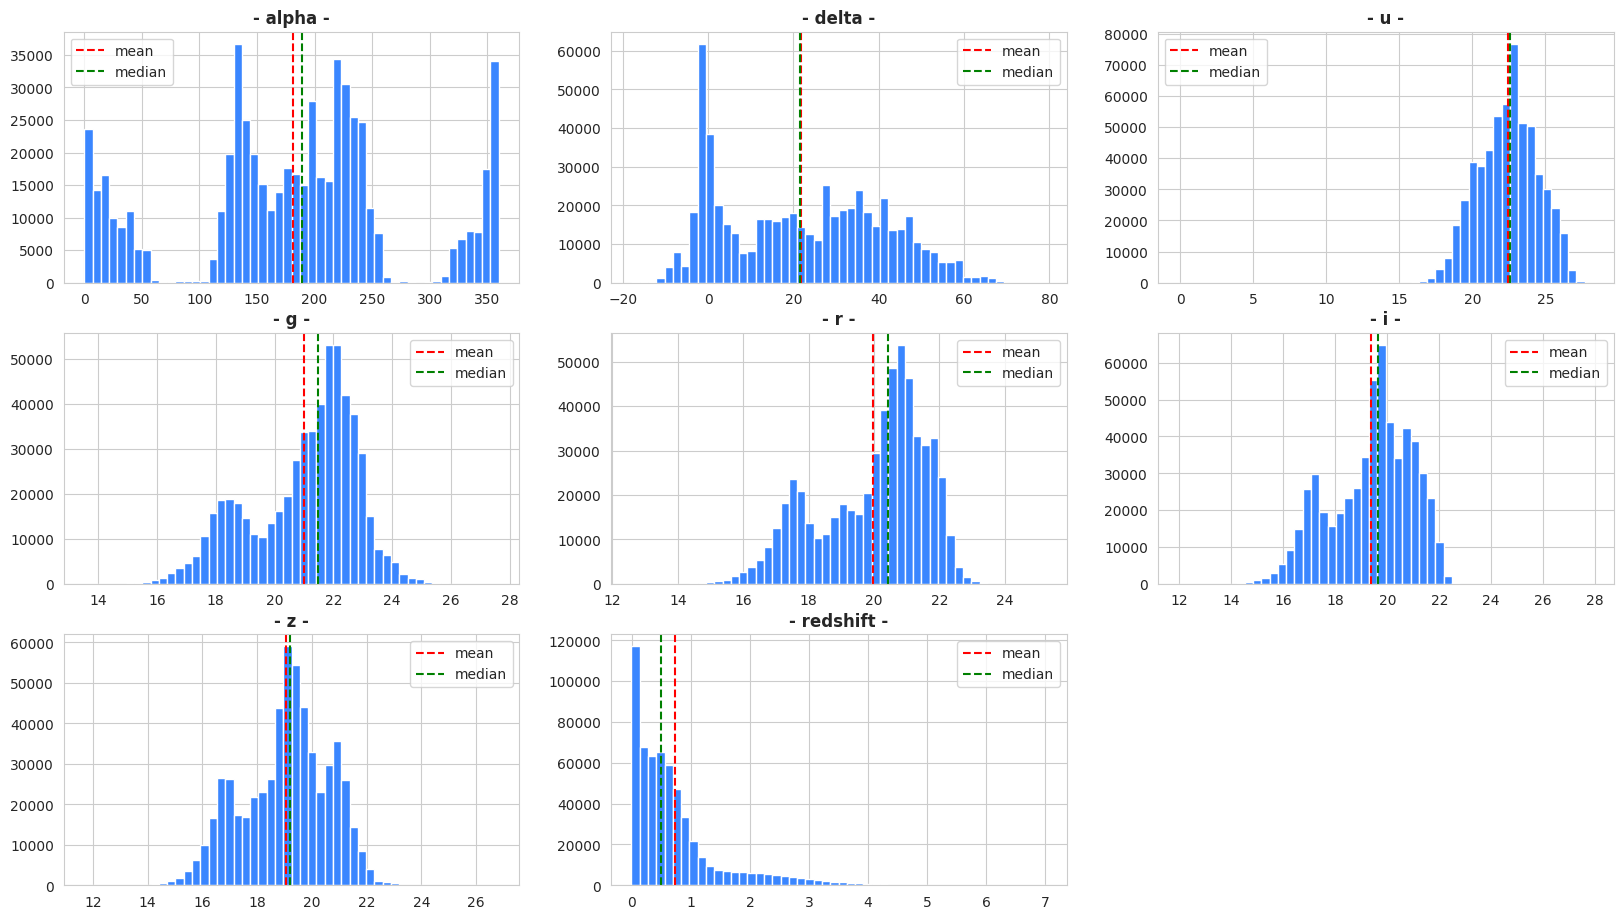

In [10]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'- {col} -', fontweight='semibold')
    plt.legend()
    
plt.show()

In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
Train,439819,444062,577347,577347,577347,577347,577347,573975,4,2
Original,99999,99999,93748,92651,91901,92019,92007,99295,4,2
Test,200893,201819,247435,247435,247435,247435,247435,246031,4,2


## FEATURE ENGINEERING

In [12]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [13]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, categories):
    for c in categories:
        X[c] = X[c].factorize()[0]
        X[c] = X[c].astype('category')
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
    
    ## -- Compute Model Importances --
    print(' • Training base model... ', end='')
    model.fit(X_train, y_train, sample_weight=get_weights(y_train, y))
    model_importances = pd.Series(model.feature_importances_, index=X.columns)
    print('Complete!')

    ## -- Compute Permutation Importances --
    print(' • Training permutation... ', end='')
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, # max_samples=0.8,
        sample_weight=get_weights(y_test, y),
        scoring='balanced_accuracy',
        random_state=42, n_jobs=-1
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print('Complete!')

    fig, axs = plt.subplots(1, 2, figsize=(15, 8))
    model_importances.sort_values().plot.barh(ax=axs[0])
    axs[0].set_xlabel("Model importance")
    
    axs[1].boxplot(
        result.importances[perm_sorted_idx].T, orientation='horizontal',
        tick_labels=X.columns[perm_sorted_idx], whis=(0, 100),
    )
    axs[1].axvline(x=0, color="k", linestyle="--")
    axs[1].set_xlabel("Permutaion importance")

    fig.suptitle("Impurity-based vs. permutation importances on validation data")
    _ = fig.tight_layout()

print('Plot function script ready!')

Plot function script ready!


In [14]:
# %%time 

# PARAMS = {
#     'loss_function': 'MultiClass',
#     'eval_metric': 'MultiClass',
#     'classes_count': 3,
#     'cat_features': CATS,
#     'random_state': CFG['SEED'],
#     'verbose': False,
#     'allow_writing_files': False,
#     'thread_count': -1,
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# model = cgb.CatBoostClassifier(**PARAMS)

# plot_permutation_importance(model, train[BASE], train[TARGET], CATS)

In [15]:
# ## -- Optimal Binning --
# try:
#     import optbinning
# except:
#     %pip install -q -U optbinning
#     import optbinning

# def _opt_multiclass_binning(
#     x_tr, y_tr, x_vl, x_ts, bin_features,
#     solver='cp', metric='mean_woe', pre_bins=100, period=100):
#     """
#     metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
#     """
#     x_train = x_tr.copy()
#     x_valid = x_vl.copy()
#     x_test  = x_ts.copy()

#     opt_modules_per_col = []
#     opt_cols = []

#     for col in tqdm(bin_features, desc='Optimal_Multiclass_Binning'):
#         # print(f'{col}... ', end='')
#         opt_multi_b = optbinning.MulticlassOptimalBinning(
#             name=col,
#             prebinning_method='cart', # d='cart', 'quantile'
#             min_prebin_size=0.02, # d=0.05
#             max_n_prebins=pre_bins, # d=20
#             # min_n_bins=2, max_n_bins=100,
#             # min_bin_size=0.1, max_bin_size=0.9,
#             solver=solver,
#             time_limit=period, # d=100 (secs)
#             # verbose=True,
#         )

#         opt_multi_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())
#         # display(optb.information(print_level=0))

#         new_col = f'{col}_optBin'
#         x_train.loc[:, new_col] = opt_multi_b.transform(x_train[col].to_numpy(), metric=metric)
#         x_valid.loc[:, new_col] = opt_multi_b.transform(x_valid[col].to_numpy(), metric=metric)
#         x_test.loc[:, new_col]  = opt_multi_b.transform(x_test[col].to_numpy(),  metric=metric)

#         opt_cols.append(new_col)
#         opt_modules_per_col.append(opt_multi_b)

#     # print(f'Done!')

#     return opt_modules_per_col, opt_cols, x_train, x_valid, x_test

# print('Binning function ready')

In [16]:
# opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_multiclass_binning(
#     x_tr=train,
#     y_tr=train[TARGET],
#     x_vl=orig,
#     x_ts=test,
#     bin_features=NUMS,
#     solver='cp', # 'cp', 'mip', 'lr'
#     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#     pre_bins=100, 
#     period=100,
# )

# print(f"Total bin features: {len(opt_bin_cols)}")
# train2.head()

In [17]:
# BIN_TABLES = []

# for opt_ in opt_bins:
#     # print(opt_bins[col_n].status, opt_bins[col_n].splits)
#     opt_table = opt_.binning_table
#     opt_table.build()
#     # display(opt_table.build())
#     BIN_TABLES.append(opt_table)

# print('Optimal Binned Features:', len(BIN_TABLES))
# print('Classes:', BIN_TABLES[0].classes)

# ## -- Plot optimal bin points --
# for i, opt_ in enumerate(BIN_TABLES):
#     opt_.plot(show_bin_labels=True, figsize=(18, 5))
#     print()

In [18]:
# for col in opt_bin_cols:
#     print(f"{col}: {train2[col].nunique()}")

In [19]:
# BIN_TABLES[0].analysis()

In [20]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [21]:
for col in ['alpha', 'delta', 'redshift']:
    print(f"\nRounding... ", end='')
    for r in range(-3, 6):
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    # print(f"\nDigitizing... ", end='')
    # for d in range(-3, 7):
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nEqual binning... ", end='')
    # for b in [32, 64, 128]: # 100, 500, 1000
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQuantile binning... ", end='')
    # for q in [32, 64, 128]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ ROUNDS: {len(ROUNDS)}')
print(f"✅ DIGITS: {len(DIGITS)}")
print(f"✅ E_BINS: {len(E_BINS)}")
print(f"✅ Q_BINS: {len(Q_BINS)}")


Rounding... alpha_round_-3, alpha_round_-2, alpha_round_-1, alpha_round_0, alpha_round_1, alpha_round_2, alpha_round_3, alpha_round_4, alpha_round_5, 
Rounding... delta_round_-3, delta_round_-2, delta_round_-1, delta_round_0, delta_round_1, delta_round_2, delta_round_3, delta_round_4, delta_round_5, 
Rounding... redshift_round_-3, redshift_round_-2, redshift_round_-1, redshift_round_0, redshift_round_1, redshift_round_2, redshift_round_3, redshift_round_4, redshift_round_5, 
✅ ROUNDS: 21
✅ DIGITS: 0
✅ E_BINS: 0
✅ Q_BINS: 0


In [22]:
for col in ['delta']: # 'u', 'g', 'r', 'i', 'z',
    # print(f"\nRounding... ", end='')
    # for r in range(-3, 5):
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')
    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)
    
    # print(f"\nExtracting digits... ", end='')
    # for d in range(-3, 6):
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nEqual binning... ", end='')
    # for b in [100]: # 50, 100, 400
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)
        
    print(f"\nQuantile binning.. ", end='')
    for q in [90, 180, 360]: 
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ ROUNDS: {len(ROUNDS)}')
print(f"✅ DIGITS: {len(DIGITS)}")
print(f"✅ E_BINS: {len(E_BINS)}")
print(f"✅ Q_BINS: {len(Q_BINS)}")


Quantile binning.. delta_Qbin_90, delta_Qbin_180, delta_Qbin_360, 
✅ ROUNDS: 21
✅ DIGITS: 0
✅ E_BINS: 0
✅ Q_BINS: 3


In [23]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: ['alpha_round_-3', 'delta_round_-3', 'delta_round_-2', 'redshift_round_-3', 'redshift_round_-2', 'redshift_round_-1']


In [24]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()

#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# for df in [train, test, orig]:
#     df = add_frequency_condition(df, DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [25]:
# ## -- Arithmetic interaction --

# for df in tqdm([train, test, orig]):
#     df['u_g_sub_'] = df['u'] - df['g']
#     df['g_r_sub_'] = df['g'] - df['r']

#     df['g_i_sub_'] = df['g'] - df['i']
#     df['r_z_sub_'] = df['r'] - df['z']

#     df['i_z_sub_'] = df['i'] - df['z']
#     df['r_i_sub_'] = df['r'] - df['i']
#     df['u_z_sub_'] = df['u'] - df['z']
    
#     df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"_div_{band}_redshift"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
# color_bands.append('stellar_locus_dist')

# train[color_bands].describe()

In [26]:
## -- Arithmetic interaction --
BANDS = ['u', 'g', 'r', 'i', 'z']
COLOR_PAIRS = [
    ('u', 'g'),
    ('g', 'r'),
    ('i', 'z'),
    ('r', 'z'),
    ('u', 'z'),
    ('r', 'i'),
]

for df in tqdm([train, test, orig]):
    for a, b in COLOR_PAIRS:
        df[f"_{a}_{b}"] = (df[a] - df[b]).astype('float32')

    for band in BANDS:
        # df[f"_div_{band}_redshift"] = (df[band] / (df['redshift'] + 1e-6)).astype('float32')
        df[f"_div_abs_{band}_redshift"] = (df[band] / (df['redshift'].abs() + 1e-6)).astype('float32')

    df['_log_redshift'] = np.log1p(df['redshift']).astype('float32')
    df['_sky_dist'] = np.sqrt(df['alpha']**2 + df['delta']**2)
    df['_stellar_locus_dist'] = np.sqrt((df['_g_r'] - 0.52)**2 + (df['_r_i'] - 0.25)**2)

    # df["_mean_bands"] = df[BANDS].mean(axis=1)
    # df["_std_bands"] = df[BANDS].std(axis=1)
    # df["_skew_bands"] = df[BANDS].skew(axis=1)
    # df["_max_bands"] = df[BANDS].max(axis=1)
    # df["_min_bands"] = df[BANDS].min(axis=1)
    # df["_range_bands"] = df["_max_bands"] - df["_min_bands"]

  0%|          | 0/3 [00:00<?, ?it/s]

In [27]:
## -- Cyclic encoding --
for df in tqdm([train, test, orig]):
    for col in ['alpha', 'delta']:
        for p in [180, 360]:
            df[f"_{col}_sin_{p}"] = np.sin(2 * np.pi * df[col] / p).astype('float32')
            df[f"_{col}_cos_{p}"] = np.cos(2 * np.pi * df[col] / p).astype('float32')

  0%|          | 0/3 [00:00<?, ?it/s]

In [28]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [29]:
INTER = []

for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
    n_col = f"_Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
#     n_col = f"_Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
#     n_col = f"_Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total interaction features: {len(INTER)}")

train[INTER].head()

Pairwise:   0%|          | 0/1 [00:00<?, ?it/s]

Total interaction features: 1


,_Bi_spectral_type-|-galaxy_population
0,M_Red_Sequence
1,M_Red_Sequence
2,O/B_Blue_Cloud
3,M_Red_Sequence
4,M_Red_Sequence


In [30]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [31]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== CategoryMeanEncoder =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [32]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_valid.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [33]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Total original features: {len(ORIG_COLS)}")

In [34]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [35]:
## -- Factorize using combined data --
for c in tqdm(CATS+INTER): 
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[len(train)+len(test):]

print('Label encoding complete!')

  0%|          | 0/3 [00:00<?, ?it/s]

Label encoding complete!


In [36]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 57


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,alpha_round_-2,alpha_round_-1,alpha_round_0,alpha_round_1,alpha_round_2,alpha_round_3,alpha_round_4,alpha_round_5,delta_round_-1,delta_round_0,delta_round_1,delta_round_2,delta_round_3,delta_round_4,delta_round_5,redshift_round_0,redshift_round_1,redshift_round_2,redshift_round_3,redshift_round_4,redshift_round_5,delta_Qbin_90,delta_Qbin_180,delta_Qbin_360,_u_g,_g_r,_i_z,_r_z,_u_z,_r_i,_div_abs_u_redshift,_div_abs_g_redshift,_div_abs_r_redshift,_div_abs_i_redshift,_div_abs_z_redshift,_log_redshift,_sky_dist,_stellar_locus_dist,_alpha_sin_180,_alpha_cos_180,_alpha_sin_360,_alpha_cos_360,_delta_sin_180,_delta_cos_180,_delta_sin_360,_delta_cos_360,_Bi_spectral_type-|-galaxy_population
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,100,150,148,147,147,147,147,147,20,17,17,16,16,16,16,0,0,0,0,0,0,38,77,155,3.576564,1.537632,0.636056,1.736869,6.851065,1.100813,62.281574,53.536564,49.776917,47.085331,45.530121,0.342868,148.704497,1.326446,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832,0.291692,0.956512,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,100,130,128,128,127,127,127,127,30,32,32,32,32,32,32,0,0,0,0,0,0,59,119,238,1.691447,1.499854,0.439634,0.800775,3.992076,0.361141,131.528854,120.821922,111.327782,109.041748,106.258842,0.146673,132.012922,0.986137,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461,0.535041,0.844826,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,1,200,180,180,179,179,179,179,179,40,35,35,35,35,35,35,3,2,2,2,2,2,64,129,258,-0.043925,-0.092712,0.025263,0.614474,0.477837,0.589211,7.449330,7.464886,7.497719,7.289058,7.280111,1.341237,183.233878,0.700343,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684,0.578496,0.815685,1


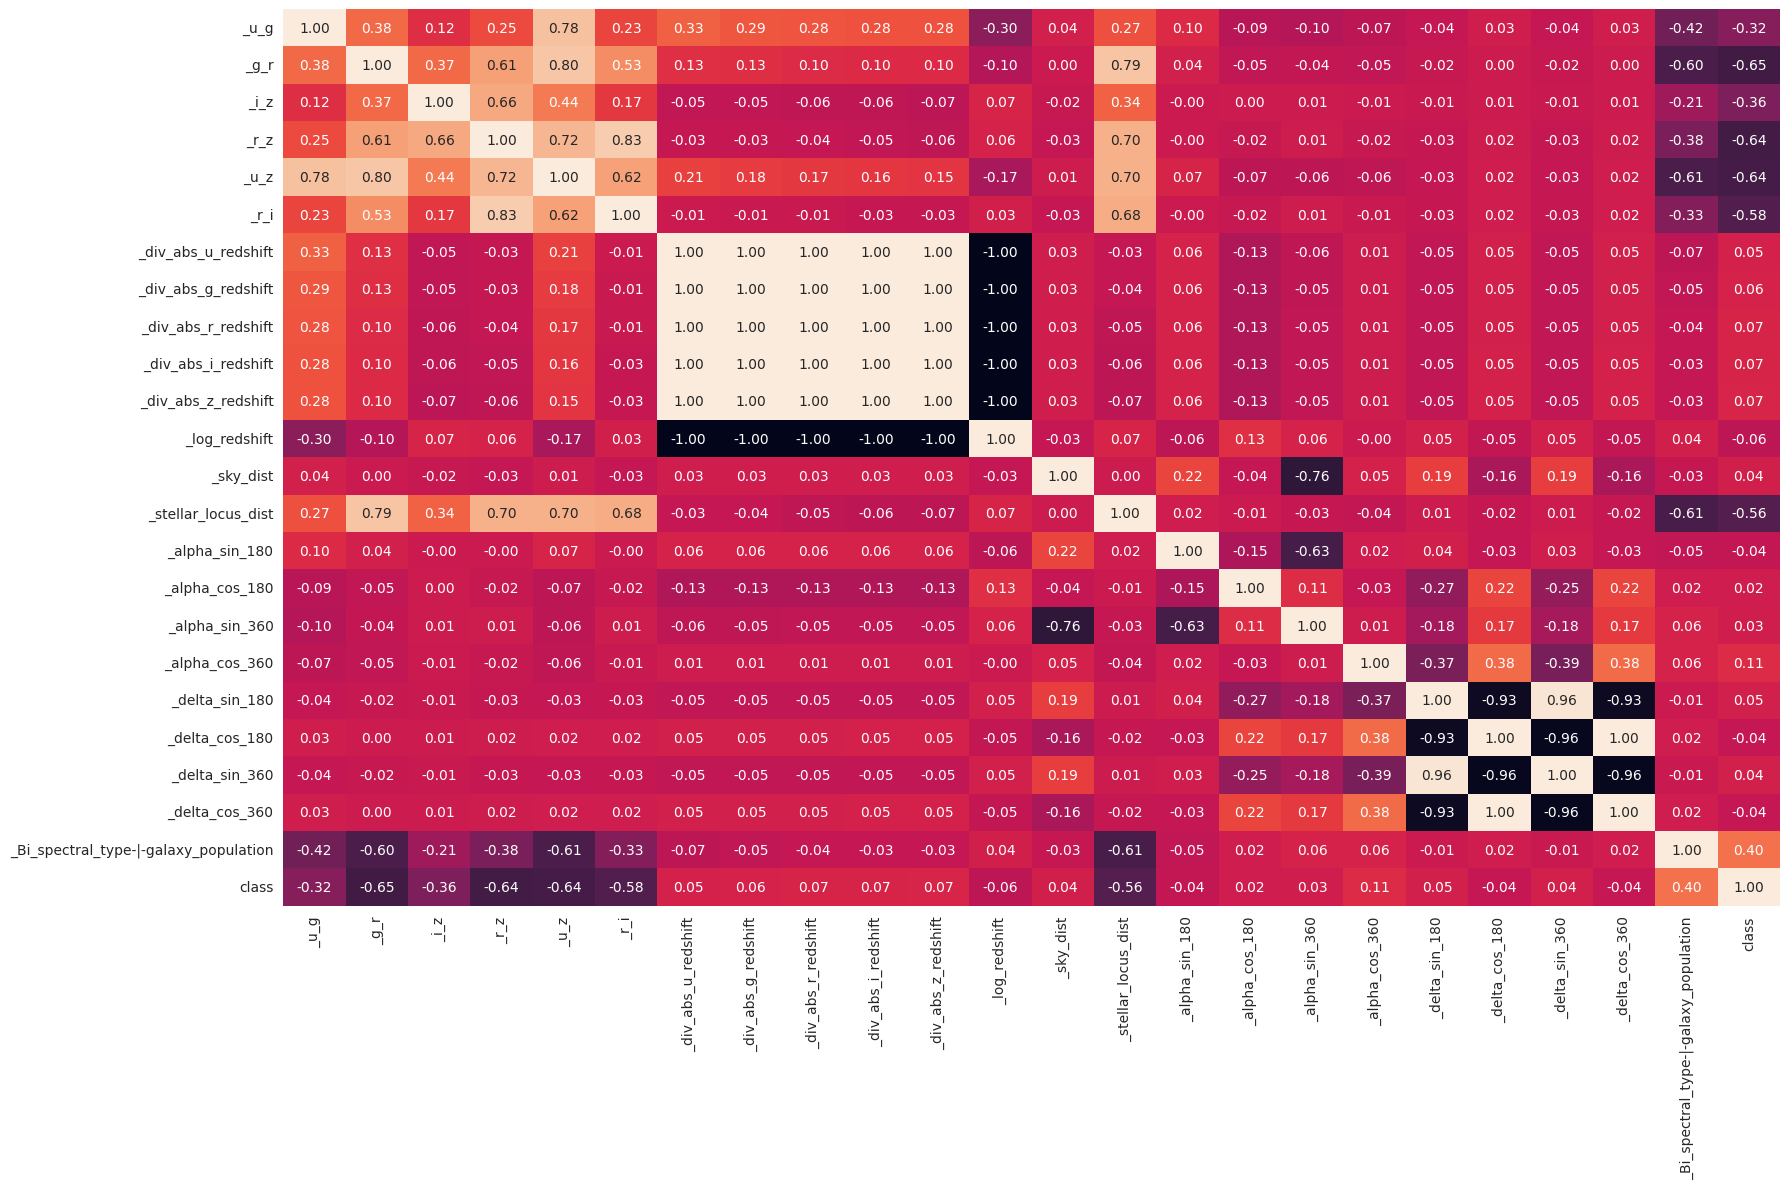

In [37]:
_ = [c for c in train.columns if c.startswith("_")]+[TARGET]

plt.figure(figsize=(18, 12))
sns.heatmap(train[_].corr("spearman"), annot=True, fmt='.2f', cbar=False)
plt.tight_layout()
plt.show()

# ML TRAINING

In [38]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q -U venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

print()
!pip show venn_abers

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.

Name: venn-abers
Version: 1.5.3
Summary: Venn-ABERS calibration package
Home-page: https://github.com/ip200/venn-abers
Author: Ivan Petej
Author-email: ivan@algorhythmic.ai
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, scikit-learn
Required-by: 


In [39]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cat_cols, calibrator='iso'):
    print(f"\n===== Starting Cross-Validation for {model_name} =====")
    start = time()

    X = train_df[features] #.sample(frac=0.3, random_state=0)
    y = train_df[target] #.iloc[X.index]

    num_classes = y.nunique()

    class_weight_dict = {0: 0.6478731615859317, 1: 0.5804348658766916, 2: 398.17679096918584}
    
    oof_preds = np.zeros((len(X), num_classes))
    test_preds = np.zeros((len(test_df), num_classes))
    fold_scores = []

    calib_oof_preds = np.zeros((len(X), num_classes))
    calib_test_preds = np.zeros((len(test_df), num_classes))
    calib_fold_scores = []

    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} *****")

        ## -- Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # print(f"CategoryMeanEncoding: {len(cats)}")
        # cm_enc  = CategoryMeanTransformer(cat_cols=cats)
        # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
        # X_valid   = cm_enc.transform(X_valid).fillna(-1)
        # X_test  = cm_enc.transform(X_test).fillna(-1)

        # _, OPT_COLS, X_train, X_valid, X_test = _opt_multiclass_binning(
        #     x_tr=X_train,
        #     y_tr=y_train,
        #     x_vl=X_valid,
        #     x_ts=X_test,
        #     bin_features=NUMS,
        #     solver='cp', # 'cp', 'mip', 'lr'
        #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
        #     pre_bins=100, 
        #     # period=300,
        # )

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cats:
        #     combined[c] = combined[c].astype(str)
        # X_train = combined.iloc[:len(X_train)]
        # X_valid   = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]


        # ## -- Target Encoding -- 
        # te_cols = ROUNDS # + DIGITS #+ OPT_COLS #+ CATS_2
        # print(f" • Target Encoding {len(te_cols)} features... ")
        # X_train, X_valid, X_test = t_enc_multi(
        #     X_train, X_valid, X_test, y_train, te_cols, drop=False
        # )

        ## -- Internal Split for Calibration --
        X_base, X_calib, y_base, y_calib = train_test_split(
            X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
        )

        print(f' • Training base model {X_base.shape}... ')
        # display(X_base.head(3))
        # CAT_COLS = cats 
        base_model = cgb.CatBoostClassifier(**params, classes_count=num_classes, cat_features=cat_cols)

        base_model.fit(
            X_base, y_base, eval_set = [(X_valid, y_valid)],
            sample_weight = get_weights(y_base, y_train),
            early_stopping_rounds = 150, verbose = 1000,
        )

        feat_importances.append(base_model.get_feature_importance(prettified=True))

        oof_preds[val_idx] = base_model.predict_proba(X_valid)
        test_preds += base_model.predict_proba(X_test)

        fold_score = balanced_acc(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        ## ----------------------------------------------------
        # if calibrator == 'sigmoid':
        #     print(f' • Training Platt Calibrator {X_calib.shape} | ', end='')
        #     calib_model = CalibratedClassifierCV(FrozenEstimator(base_model), cv=None, method='sigmoid', n_jobs=-1)
        #     calib_model.fit(X_calib, y_calib, sample_weight=get_weights(y_calib, y_train))

        #     calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
        #     calib_test_preds += calib_model.predict_proba(X_test)

        #     calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
        #     calib_fold_scores.append(calib_fold_score)
        #     print(calib_oof_preds[val_idx].shape, calib_test_preds.shape)

        if calibrator == 'iso':
            print(f' • Calibrating model {X_calib.shape} | ', end='')
            calib_model = CalibratedClassifierCV(
                FrozenEstimator(base_model), cv=None, method='isotonic', n_jobs=-1
            )
            calib_model.fit(X_calib, y_calib, sample_weight=get_weights(y_calib, y_train))

            calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
            calib_test_preds += calib_model.predict_proba(X_test)
    
            calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
            calib_fold_scores.append(calib_fold_score)
            print(calib_oof_preds[val_idx].shape, calib_test_preds.shape)
        elif calibrator == 'venn_one':
            print(f' • Training Venn-Abers 1-vs-1 {X_calib.shape} | ', end='')
            vao = VennAbersCalibrator() ## Get OOF predictions --
            oof_calib, oof_p0p1 = vao.predict_proba(p_cal=base_model.predict_proba(X_calib),
                                                    y_cal=y_calib.to_numpy(),
                                                    p_test=base_model.predict_proba(X_valid),
                                                    p0_p1_output=True, va_type='one_vs_one')
            calib_oof_preds[val_idx] = oof_calib

            vat = VennAbersCalibrator() ## Get TEST predictions --
            test_calib, test_p0p1 = vat.predict_proba(p_cal=base_model.predict_proba(X_calib),
                                                      y_cal=y_calib.to_numpy(),
                                                      p_test=base_model.predict_proba(X_test),
                                                      p0_p1_output=True, va_type='one_vs_one')
            calib_test_preds += test_calib

            calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
            calib_fold_scores.append(calib_fold_score)
            print(oof_calib.shape, test_calib.shape)
        elif calibrator == 'venn_all':
            print(f' • Training Venn-Abers 1-vs-all {X_calib.shape} | ', end='')
            vao = VennAbersCalibrator() ## Get OOF predictions --
            oof_calib, oof_p0p1 = vao.predict_proba(p_cal=base_model.predict_proba(X_calib),
                                                    y_cal=y_calib.to_numpy(),
                                                    p_test=base_model.predict_proba(X_valid),
                                                    p0_p1_output=True, va_type='one_vs_all')
            calib_oof_preds[val_idx] = oof_calib

            vat = VennAbersCalibrator() ## Get TEST predictions --
            test_calib, test_p0p1 = vat.predict_proba(p_cal=base_model.predict_proba(X_calib),
                                                      y_cal=y_calib.to_numpy(),
                                                      p_test=base_model.predict_proba(X_test),
                                                      p0_p1_output=True, va_type='one_vs_all')
            calib_test_preds += test_calib

            calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
            calib_fold_scores.append(calib_fold_score)
            print(oof_calib.shape, test_calib.shape)

        base_loss  = log_loss(y_valid, oof_preds[val_idx])
        calib_loss = log_loss(y_valid, calib_oof_preds[val_idx])

        print(f"{CFG['YELLOW']} • Fold {idx+1} results -------------------------------")
        print(f"bal_acc:  base -> {fold_score:.5f} | calib -> {calib_fold_score:.5f}")
        print(f'log_loss: base -> {base_loss:.5f} | calib -> {calib_loss:.5f}{CFG['RESET']}')
        ## ----------------------------------------------------
    
    # Average test predictions
    test_preds /= kf.n_splits
    calib_test_preds /= kf.n_splits

    # Print final cross-validation results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, (b, c) in enumerate(list(zip(fold_scores, calib_fold_scores)), 1):
        print(f" • Fold {i}: base -> {b:.5f} | calib -> {c:.5f}")

    overall_score = np.round(balanced_acc(y, oof_preds), 5)
    calib_overall_score = np.round(balanced_acc(y, calib_oof_preds), 5)
    
    print(f"{'='*40}")
    print(f"OOF: Base -> {overall_score} | Calib -> {calib_overall_score}")
    print(f"{'-'*40}")
    print(f"AVG  Base: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"AVG Calib: {np.mean(calib_fold_scores):.5f} ± {np.std(calib_fold_scores):.5f}")
    print(f"{'-'*40}")
    print(f"{CFG['GREEN']}Improved: {calib_overall_score - overall_score:.5f}{CFG['RESET']}")
    print(f"{'='*40}")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'scores': [overall_score, calib_overall_score],
        'models': base_model,
        'oof_preds': [oof_preds, calib_oof_preds],
        'test_preds': [test_preds, calib_test_preds],
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [40]:
!rm -r /kaggle/working/

rm: cannot remove '/kaggle/working/': Device or resource busy


In [41]:
version_name = 'cat_fe0_'
all_model_predictions = {}

ALL_CATS = CATS + INTER + ROUNDS

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

CFG['FOLDS'] = 5
kf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [42]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# # if all_model_predictions:
# #     all_model_predictions.clear()

# M_NAME = version_name 
# COMPILER = []

# OUT_LOOP = [0]
# INN_LOOP = [0]
# p_name   = ['-', '-']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'boosting_type': value,
#             # ---------------------------------
#             'grow_policy': 'SymmetricTree',
#             # ---------------------------------
#             'bootstrap_type': 'Bayesian',
#             'bagging_temperature': 0.5,
#             # 'random_strength': 1.0,
#             # ---------------------------------
#             'loss_function': 'MultiClass',
#             'eval_metric': 'MultiClass',
#             'n_estimators': 10_000,
#             'learning_rate': 0.1,
#             'depth': 4,
#             'l2_leaf_reg': 1.0,
#             'thread_count': os.cpu_count(),
#             'allow_writing_files': False,
#             'random_state': CFG['SEED'],
#             'verbose': 0,
#             'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=ALL_CATS,
#             # calibrator='venn_all', # def='isotonic', 'venn_one', 'venn_all'
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} model(s) ======\n")

In [43]:
# -- base + formula(both) + ORIG + TE(CATS_2_ROUNDS_DIGITS_INTER(top2_top3_top2low))
# lr=0.1__dep=4__l2=1.0
# ==================================================
# Cross-Validation Results
# ==================================================
#  • FOLD 1: base -> 0.97691 | calib -> 0.97893
#  • FOLD 2: base -> 0.97726 | calib -> 0.97985
#  • FOLD 3: base -> 0.97951 | calib -> 0.98086
#  • FOLD 4: base -> 0.97742 | calib -> 0.97992
#  • FOLD 5: base -> 0.97790 | calib -> 0.98000
# ========================================
# OOF:  BASE -> 0.9778 | CALIB -> 0.97991
# ----------------------------------------
# AVG  Base: 0.97780 ± 0.00091
# AVG Calib: 0.97991 ± 0.00061
# ----------------------------------------
# Improved: 0.00211
# ========================================
# 36.53 mins

In [44]:
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'scores':
#                 all_model_scores[model_name] = value

# raw_scores, calib_scores, names = [], [], []

# for k, group in all_model_scores.items():
#     raw_scores.append(group[0])
#     calib_scores.append(group[1])
#     names.append(k)

# plt.figure(figsize=(15, 6))
# ax1 = sns.lineplot(raw_scores, marker='s', label='base_model')
# ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')

# y_add = 4e-4

# for i, s1 in enumerate(raw_scores):
#     ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

# for i, s2 in enumerate(calib_scores):
#     ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')

# plt.ylim((0.97, 0.99))
# plt.legend(loc='upper center')
# plt.xticks(range(len(names)), names, rotation=30)
# plt.title('Base vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})

# plt.tight_layout() 
# plt.show()

In [45]:
# all_feat_importances = {}
# all_val_data = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'importances':
#                 all_feat_importances[model_name] = value #np.mean(value, axis=0)
#             elif key == 'val_data':
#                 all_val_data[model_name] = value # -> [0] select X_valid, [1] select y_valid

# all_df_ = []
# top_n = 25

# for i, (k, df) in enumerate(all_feat_importances.items()):
#     df_merge = df[0].merge(df[1], how='left', on='Feature Id', suffixes=('_0', '_1'))\
#                     .merge(df[2], how='left', on='Feature Id', suffixes=('_2', '_3'))\
#                     .merge(df[3], how='left', on='Feature Id', suffixes=('_3', '_4'))\
#                     .merge(df[4], how='left', on='Feature Id', suffixes=('_4', '_5'))

#     df_final = pd.concat([df[0]['Feature Id'], df_merge.drop(columns=['Feature Id']).mean(axis=1)], axis=1)\
#                                                        .rename(columns={0: 'score'})\
#                                                        .sort_values(by='score')

#     ax = df_final.tail(top_n).plot.barh(y='score', x='Feature Id', figsize=(15, 8))
#     ax.set_title(f"{k} Avg. {CFG['FOLDS']}-Fold Feature Importances", fontweight='semibold')

#     plt.tight_layout()
#     plt.show()

#     print()


In [46]:
## =========== BOOSTING TYPE: PLAIN ==============
# if all_model_predictions:
#     all_model_predictions.clear()

LR        = 0.03
DEPTH     = 6
REGULATE  = 5.0
FUNCTION  = 'MultiClass'
METRIC    = 'MultiClass'
CALIBRATE = 'venn_all'

PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'SymmetricTree',
    # ---------------------------------
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0.2,
    # 'random_strength': 0.8,
    # ---------------------------------
    'iterations': 50_000,
    'loss_function': FUNCTION,
    'eval_metric': METRIC,
    'learning_rate': LR,
    # 'depth': DEPTH,
    'l2_leaf_reg': REGULATE,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': CFG['SEED'],
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = f"{version_name}bayes"

all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cat_cols=ALL_CATS,
    calibrator=CALIBRATE,
)

## ==================================================== 

# M_NAME = f"{version_name}MVS_"

# PARAMS = {
#     # 'boosting_type': 'Plain',
#     # ---------------------------------
#     'grow_policy': 'Depthwise',
#     # ---------------------------------
#     'bootstrap_type': 'MVS',
#     # 'min_data_in_leaf': 2,
#     'subsample': 0.8, # auto 0.8 for 'MVS'
#     # ---------------------------------
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     'learning_rate': LR,
#     # 'depth': 6,
#     'l2_leaf_reg': REGULATE,
#     'random_state': CFG['SEED'],
#     'verbose': 0,
#     'allow_writing_files': False,
#     'thread_count': os.cpu_count(),
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# n = M_NAME + str(LR).split('.')[1] + '_' +  str(CFG['SEED'])

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS
# )




===== Starting Cross-Validation for cat_fe0_bayes =====

***** FOLD 1/5 *****
 • Training base model (323313, 57)... 
0:	learn: 1.0514902	test: 1.0528674	best: 1.0528674 (0)	total: 229ms	remaining: 3h 11m 10s
1000:	learn: 0.1021598	test: 0.1201289	best: 0.1201289 (1000)	total: 13.7s	remaining: 11m 10s
2000:	learn: 0.0932224	test: 0.1132783	best: 0.1132773 (1999)	total: 26.3s	remaining: 10m 30s
3000:	learn: 0.0879967	test: 0.1101065	best: 0.1101065 (3000)	total: 38.9s	remaining: 10m 9s
4000:	learn: 0.0831975	test: 0.1076483	best: 0.1076483 (4000)	total: 51.6s	remaining: 9m 53s
5000:	learn: 0.0791590	test: 0.1060058	best: 0.1060058 (5000)	total: 1m 4s	remaining: 9m 40s
6000:	learn: 0.0754351	test: 0.1045997	best: 0.1045989 (5999)	total: 1m 17s	remaining: 9m 27s
7000:	learn: 0.0720516	test: 0.1035222	best: 0.1035222 (7000)	total: 1m 30s	remaining: 9m 16s
8000:	learn: 0.0690483	test: 0.1026404	best: 0.1026396 (7997)	total: 1m 43s	remaining: 9m 5s
9000:	learn: 0.0661957	test: 0.1018189	bes

In [47]:
# ==================================================
# Cross-Validation Results for cat_fe0_bayes
# ==================================================
#  • Fold 1: base -> 0.96021 | calib -> 0.96273
#  • Fold 2: base -> 0.96059 | calib -> 0.96296
#  • Fold 3: base -> 0.95990 | calib -> 0.96218
#  • Fold 4: base -> 0.95920 | calib -> 0.96256
#  • Fold 5: base -> 0.95806 | calib -> 0.95916
# ========================================
# OOF: Base -> 0.95959 | Calib -> 0.96192
# ----------------------------------------
# AVG  Base: 0.95959 ± 0.00089
# AVG Calib: 0.96192 ± 0.00140
# ----------------------------------------
# Improved: 0.00233
# ========================================
# 14.83 mins

In [48]:
# ## ==================================================== 

PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'Depthwise',
    # ---------------------------------
    'bootstrap_type': 'Bernoulli',
    # 'subsample': 0.8, # auto 0.66 for 'Bernoulli'
    # 'colsample_bylevel': 0.7,
    'min_data_in_leaf': 50,
    # ---------------------------------
    'iterations': 50_000,
    'loss_function': FUNCTION,
    'eval_metric': METRIC,
    'learning_rate': LR,
    # 'depth': DEPTH,
    'l2_leaf_reg': REGULATE,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': CFG['SEED'],
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = f"{version_name}bern"

all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cat_cols=ALL_CATS,
    calibrator=CALIBRATE,
)


===== Starting Cross-Validation for cat_fe0_bern =====

***** FOLD 1/5 *****
 • Training base model (323313, 57)... 
0:	learn: 1.0482217	test: 1.0492836	best: 1.0492836 (0)	total: 28.6ms	remaining: 23m 49s
1000:	learn: 0.0921879	test: 0.1144912	best: 0.1144912 (1000)	total: 12s	remaining: 9m 49s
2000:	learn: 0.0814681	test: 0.1086398	best: 0.1086398 (2000)	total: 23.7s	remaining: 9m 28s
3000:	learn: 0.0734068	test: 0.1053745	best: 0.1053745 (3000)	total: 35.3s	remaining: 9m 12s
4000:	learn: 0.0668302	test: 0.1031434	best: 0.1031434 (4000)	total: 47.5s	remaining: 9m 5s
5000:	learn: 0.0612142	test: 0.1015488	best: 0.1015488 (5000)	total: 59.2s	remaining: 8m 52s
6000:	learn: 0.0562925	test: 0.1002546	best: 0.1002546 (6000)	total: 1m 10s	remaining: 8m 35s
7000:	learn: 0.0520628	test: 0.0991919	best: 0.0991919 (7000)	total: 1m 21s	remaining: 8m 20s
8000:	learn: 0.0483186	test: 0.0984327	best: 0.0984325 (7998)	total: 1m 32s	remaining: 8m 4s
9000:	learn: 0.0449565	test: 0.0977761	best: 0.097

In [49]:
## ==================================================== 

LEAVES = 64
PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'Lossguide',
    # ---------------------------------
    'max_leaves': LEAVES,
    'min_data_in_leaf': 80,
    # ---------------------------------
    'iterations': 50_000,
    'loss_function': FUNCTION,
    'eval_metric': METRIC,
    'learning_rate': LR,
    # 'depth': DEPTH,
    'l2_leaf_reg': REGULATE,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': CFG['SEED'],
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = f"{version_name}loss"
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cat_cols=ALL_CATS,
    calibrator=CALIBRATE,
)


===== Starting Cross-Validation for cat_fe0_loss =====

***** FOLD 1/5 *****
 • Training base model (323313, 57)... 
0:	learn: 1.0482348	test: 1.0492981	best: 1.0492981 (0)	total: 41ms	remaining: 34m 11s
1000:	learn: 0.0930220	test: 0.1151113	best: 0.1151113 (1000)	total: 29.6s	remaining: 24m 7s
2000:	learn: 0.0827629	test: 0.1094868	best: 0.1094868 (2000)	total: 56.1s	remaining: 22m 26s
3000:	learn: 0.0752944	test: 0.1063839	best: 0.1063839 (3000)	total: 1m 23s	remaining: 21m 50s
4000:	learn: 0.0691466	test: 0.1041725	best: 0.1041725 (4000)	total: 1m 46s	remaining: 20m 19s
5000:	learn: 0.0638831	test: 0.1024854	best: 0.1024849 (4999)	total: 2m 11s	remaining: 19m 47s
6000:	learn: 0.0592273	test: 0.1011165	best: 0.1011165 (6000)	total: 2m 41s	remaining: 19m 44s
7000:	learn: 0.0551623	test: 0.1000674	best: 0.1000667 (6998)	total: 3m 8s	remaining: 19m 16s
8000:	learn: 0.0514358	test: 0.0992122	best: 0.0992122 (7999)	total: 3m 38s	remaining: 19m 6s
9000:	learn: 0.0481081	test: 0.0985280	b

In [50]:
#  • Fold 1 results -------------------------------
# bal_acc:  base -> 0.96127 | calib -> 0.96243
# log_loss: base -> 0.10574 | calib -> 0.11750

In [51]:
# ## =========== BOOSTING TYPE: ORDERED ==============

# PARAMS = {
#     'boosting_type': 'Ordered',
#     # ---------------------------------
#     'grow_policy': 'SymmetricTree',
#     # ---------------------------------
#     'bootstrap_type': 'Bayesian',
#     'bagging_temperature': 0.5,
#     # 'random_sampling': 0.8,
#     # ---------------------------------
#     'loss_function': FUNCTION,
#     'eval_metric': METRIC,
#     'learning_rate': LR,
#     'depth': DEPTH,
#     # 'l2_leaf_reg': REGULATE,
#     'thread_count': os.cpu_count(),
#     'allow_writing_files': False,
#     'random_state': CFG['SEED'],
#     'verbose': 0,
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# n = f"{version_name}ord_bayes_"

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cat_cols=ALL_CATS,
# )

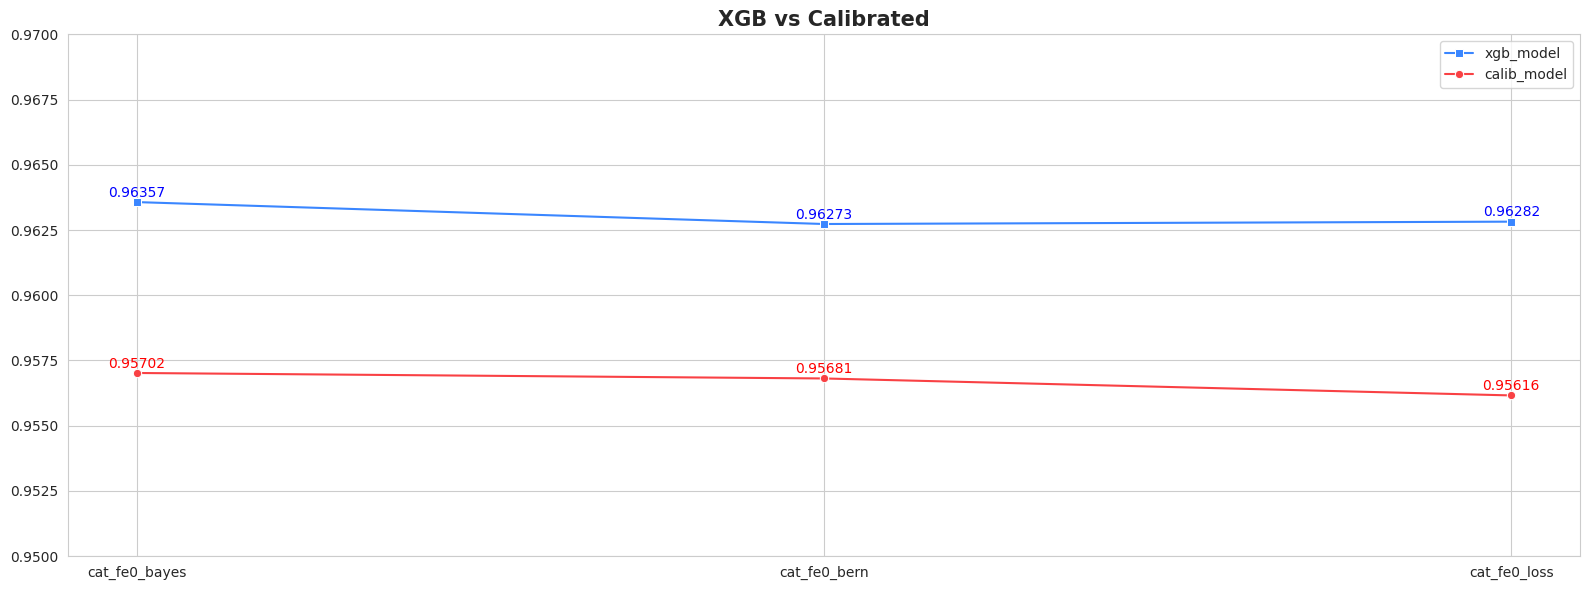

In [52]:
all_model_scores = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'scores':
            all_model_scores[k] = y

raw_scores, calib_scores, names = [], [], []

for k, group in all_model_scores.items():
    raw_scores.append(group[0])
    calib_scores.append(group[1])
    names.append(k)

plt.figure(figsize=(16, 6))
ax1 = sns.lineplot(raw_scores, marker='s', label='xgb_model')
ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')

y_add = 2e-4

for i, s1 in enumerate(raw_scores):
    ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

for i, s2 in enumerate(calib_scores):
    ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')

plt.ylim((0.95, 0.97))
plt.legend(loc='best')
plt.xticks(range(len(names)), names, rotation=0)
plt.title('XGB vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})

plt.tight_layout() 
plt.show()

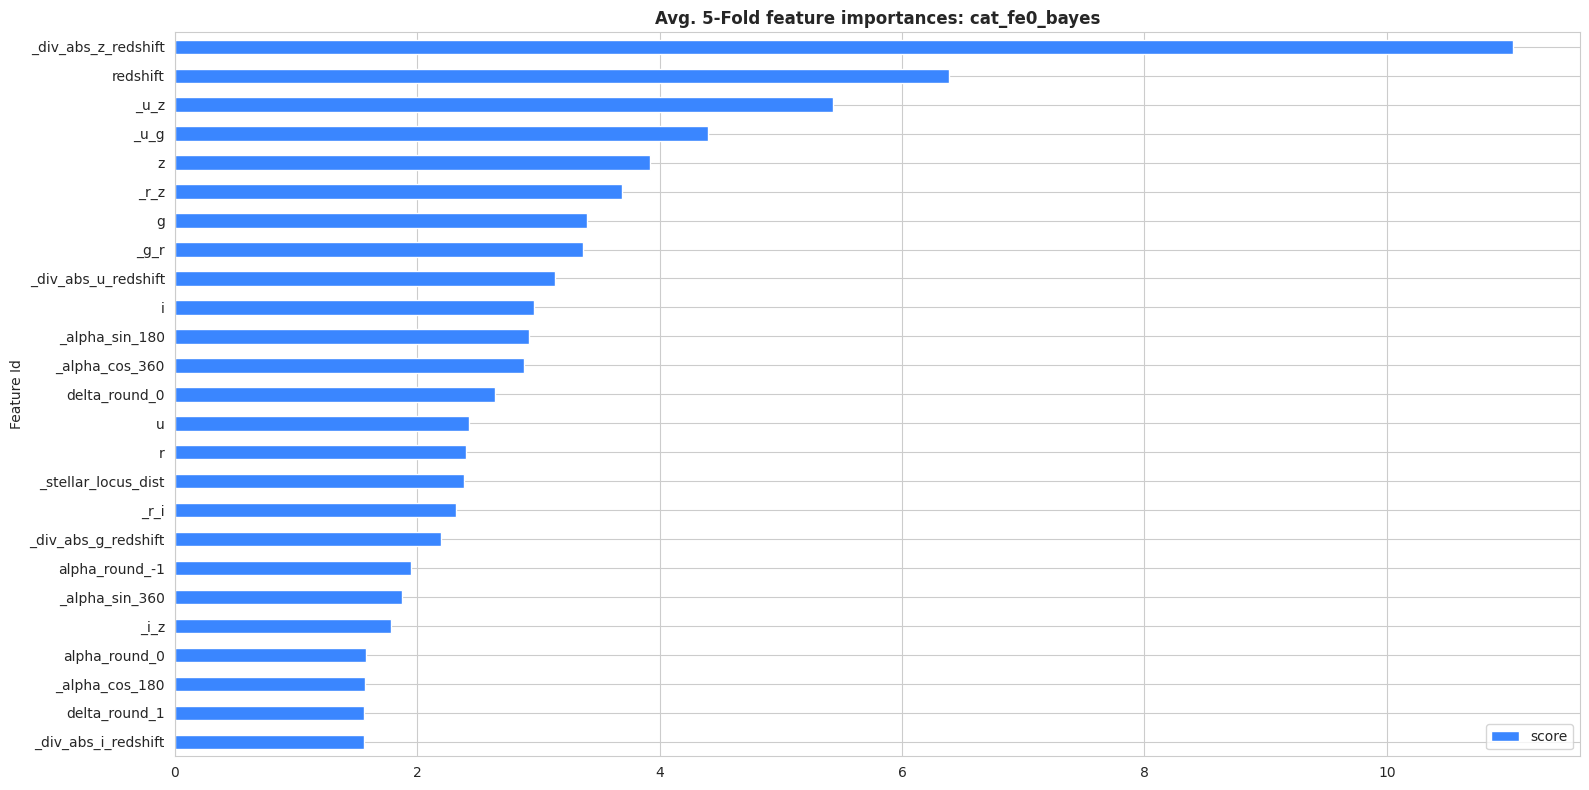

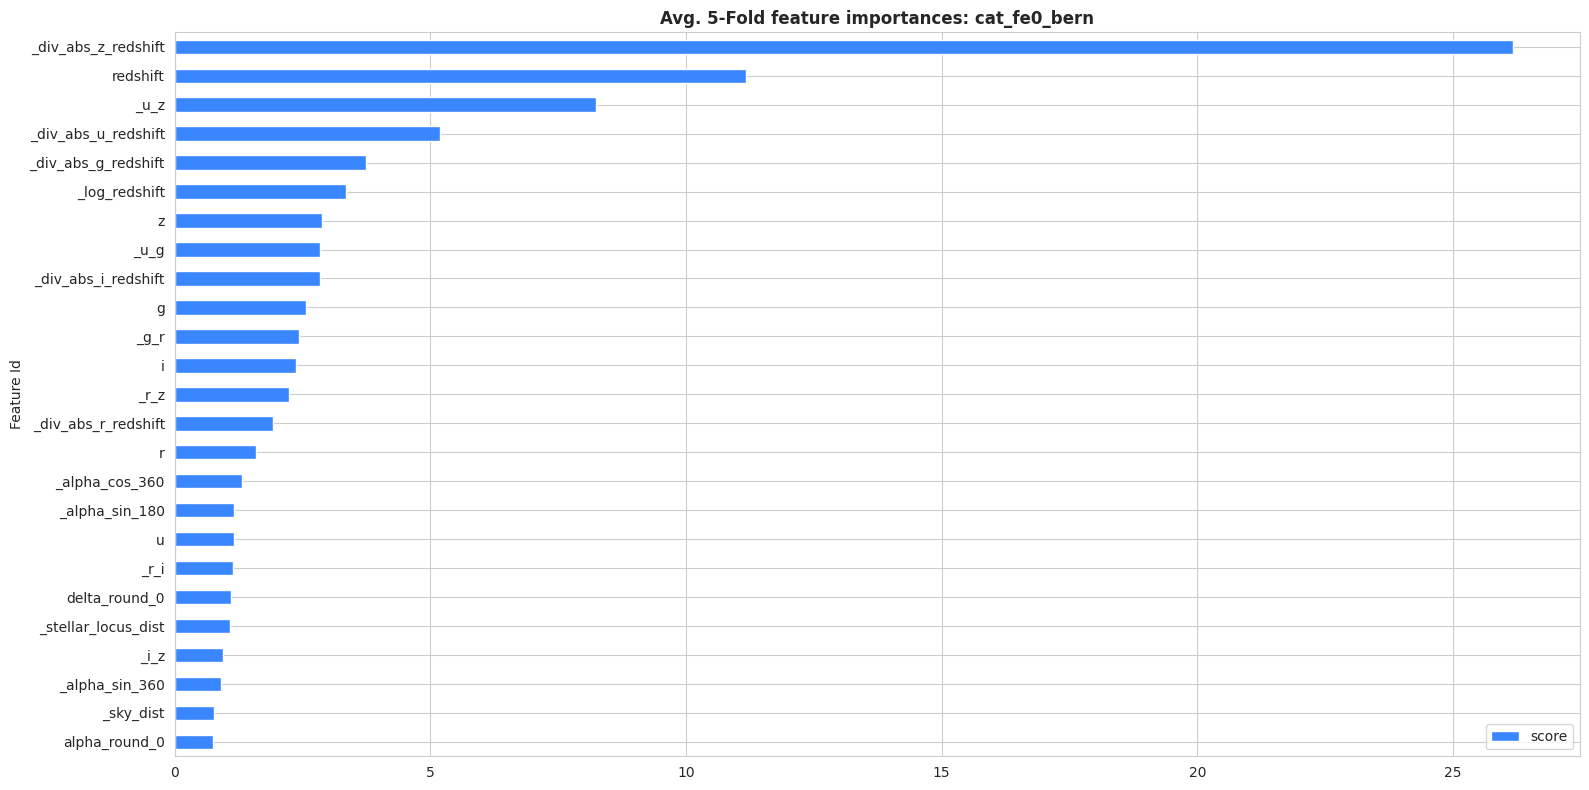

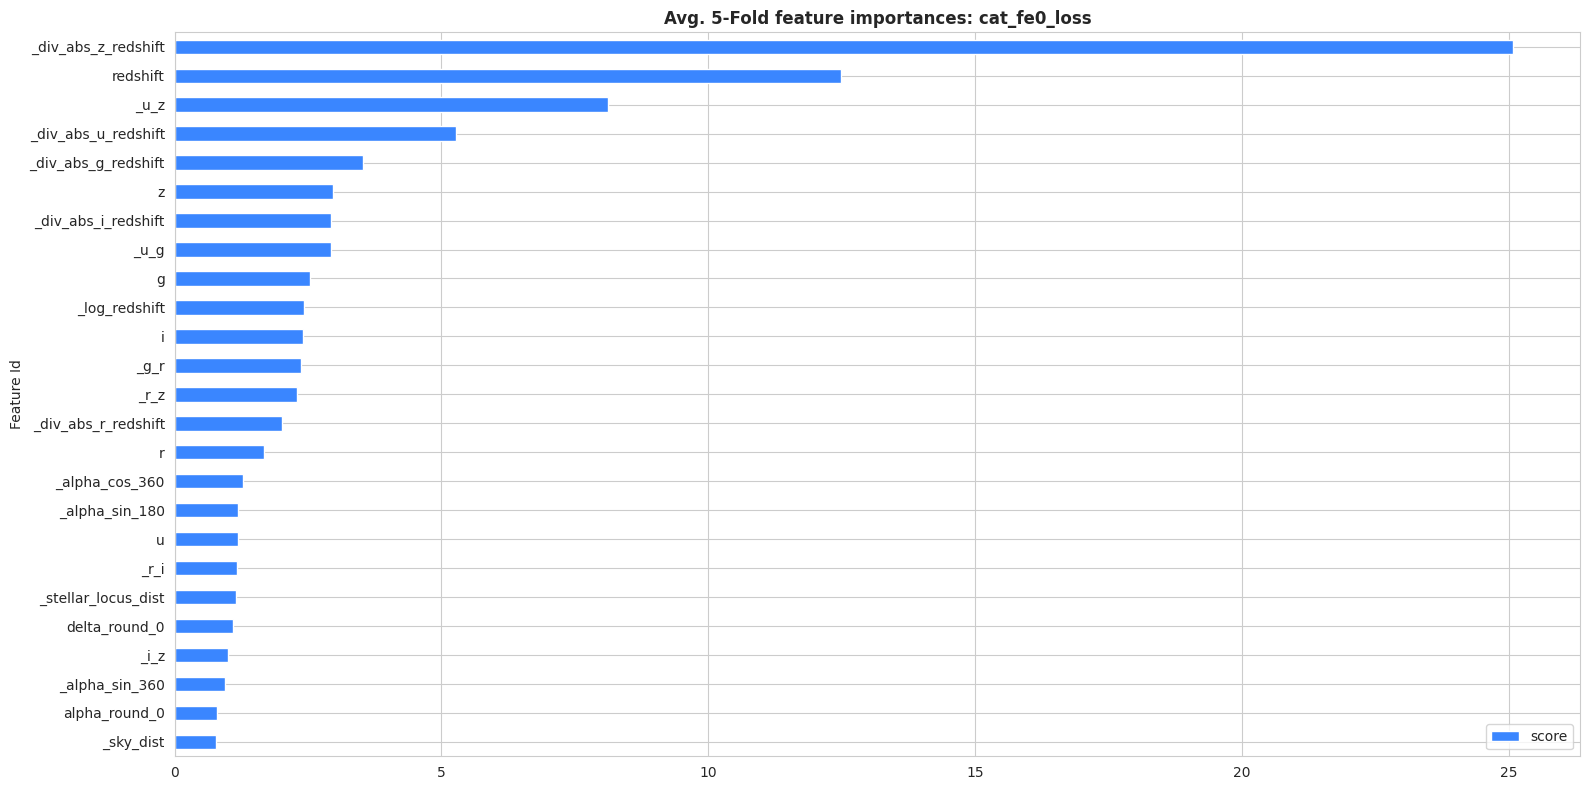

In [53]:
all_feat_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'importances':
            all_feat_importances[k] = y # np.mean(value, axis=0)
        elif x == 'val_data':
            all_val_data[k] = y # -> [0] select X_valid, [1] select y_valid

all_df_ = []
top_n = 25

for i, (k, df) in enumerate(all_feat_importances.items()):
    df_merge = df[0].merge(df[1], how='left', on='Feature Id', suffixes=('_0', '_1'))\
                    .merge(df[2], how='left', on='Feature Id', suffixes=('_2', '_3'))

    df_final = pd.concat([df[0]['Feature Id'], df_merge.drop(columns=['Feature Id'])\
                                                       .mean(axis=1)], axis=1)\
                                                       .rename(columns={0: 'score'})\
                                                       .sort_values(by='score')

    ax = df_final.tail(top_n).plot.barh(y='score', x='Feature Id', figsize=(16, 8))
    ax.set_title(f"Avg. {CFG['FOLDS']}-Fold feature importances: {k}", fontweight='semibold')

    plt.tight_layout()
    plt.show()

    print()

In [54]:
# !rm -r /kaggle/working

In [55]:
## -- Get OOF PREDICTIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            ## -- Create base submission file --
            base_n = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"oof_base_{base_n}_.npy", y[0])
            print(f"OOF {base_n} saved!")

            ## -- Create calib submission file --
            cal_n = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            np.save(f"oof_calib_{cal_n}_.npy", y[1])
            print(f'OOF {cal_n} saved!')

            print()

OOF cat_fe0_bayes_96357 saved!
OOF cat_fe0_bayes_95702 saved!

OOF cat_fe0_bern_96273 saved!
OOF cat_fe0_bern_95681 saved!

OOF cat_fe0_loss_96282 saved!
OOF cat_fe0_loss_95616 saved!



In [56]:
## -- Get TEST PREDICTIONS / SUBMISSIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            base_n_1 = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"test_base_{base_n_1}_.npy", y[0])
            base_preds = np.argmax(y[0], axis=1)
            submit[TARGET] = pd.Series(base_preds).map(r_mapping)
            submit.to_csv(f'submit_base_{base_n_1}.csv', index=False)
            print(f'Submission base TEST file saved! {base_preds.shape}')

            ## -- Calib submission file --
            cal_n_1 = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            np.save(f"test_calib_{cal_n_1}_.npy", y[1])
            calib_preds = np.argmax(y[1], axis=1)
            submit[TARGET] = pd.Series(calib_preds).map(r_mapping)
            submit.to_csv(f'submit_calib_{cal_n_1}.csv', index=False)
            print(f'Submission calib TEST file saved! {calib_preds.shape}')

            print()

Submission base TEST file saved! (247435,)
Submission calib TEST file saved! (247435,)

Submission base TEST file saved! (247435,)
Submission calib TEST file saved! (247435,)

Submission base TEST file saved! (247435,)
Submission calib TEST file saved! (247435,)



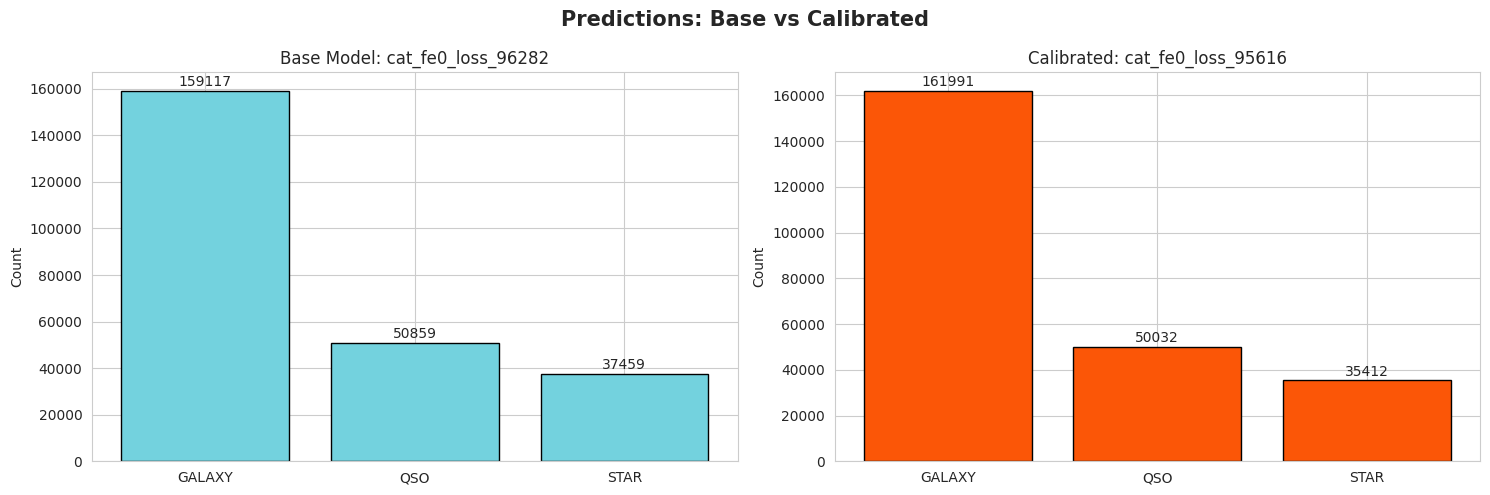

In [57]:
class_names = [k for k in mapping.keys()]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, preds, title, color in [
    (axes[0], base_preds, f'Base Model: {base_n_1}', '#73D2DE'),
    (axes[1], calib_preds, f'Calibrated: {cal_n_1}', '#FB5607'),
]:
    counts = [np.sum(preds == i) for i in range(len(np.unique(base_preds)))]
    ax.bar(class_names, counts, color=color, edgecolor='k')
    ax.set_title(title)
    ax.set_ylabel('Count')

    for i, c in enumerate(counts):
        ax.text(i, c + 2000, str(c), ha='center', fontsize=10)

plt.suptitle('Predictions: Base vs Calibrated', fontsize=15, fontweight='semibold')

plt.tight_layout()
plt.show()